#Exploratory Data Analysis On A Dataset


In [32]:
import pandas as pd
import numpy as np

In [33]:
df = pd.read_csv("Cardiotocographic (1).csv")

# **DATA CLEANING**

In [34]:
df.head()

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
0,120.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,73.0,0.5,43.0,2.4,64.0,0.999926,2.0
1,132.000000,0.006380,0.0,0.006380,0.003190,0.0,0.0,17.0,2.1,0.0,10.4,130.0,0.000000,1.0
2,133.000000,0.003322,0.0,0.008306,0.003322,0.0,0.0,16.0,2.1,0.0,13.4,130.0,0.000000,1.0
3,134.000000,0.002561,0.0,0.007742,0.002561,0.0,0.0,16.0,2.4,0.0,23.0,117.0,1.000000,1.0
4,131.948232,0.006515,0.0,0.008143,0.000000,0.0,0.0,16.0,2.4,0.0,19.9,117.0,1.000000,1.0


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   LB        2105 non-null   float64
 1   AC        2106 non-null   float64
 2   FM        2126 non-null   float64
 3   UC        2126 non-null   float64
 4   DL        2126 non-null   float64
 5   DS        2105 non-null   float64
 6   DP        2105 non-null   float64
 7   ASTV      2126 non-null   float64
 8   MSTV      2126 non-null   float64
 9   ALTV      2126 non-null   float64
 10  MLTV      2105 non-null   float64
 11  Width     2105 non-null   float64
 12  Tendency  2105 non-null   float64
 13  NSP       2105 non-null   float64
dtypes: float64(14)
memory usage: 232.7 KB


In [36]:
df.describe() # used to observe the plots

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
count,2105.000000,2106.000000,2126.000000,2126.000000,2126.000000,2105.000000,2105.000000,2126.000000,2126.000000,2126.000000,2105.000000,2105.000000,2105.000000,2105.000000
mean,133.343598,0.003219,0.009894,0.004391,0.001895,0.000003,0.000175,46.995984,1.364378,10.285964,8.284887,70.429260,0.316371,1.304507
std,11.270154,0.004391,0.067540,0.003340,0.003343,0.000142,0.000840,18.813973,1.173632,21.205041,7.772858,42.931822,0.645622,0.644619
min,51.842487,-0.019284,-0.480634,-0.014925,-0.015393,-0.001353,-0.005348,-63.000000,-6.600000,-91.000000,-50.700000,-174.000000,-3.000000,-1.025988
25%,126.000000,0.000000,0.000000,0.001851,0.000000,0.000000,0.000000,32.000000,0.700000,0.000000,4.600000,37.000000,0.000000,1.000000
50%,133.000000,0.001634,0.000000,0.004484,0.000000,0.000000,0.000000,49.000000,1.200000,0.000000,7.400000,67.000000,0.000000,1.000000
75%,140.000000,0.005650,0.002567,0.006536,0.003289,0.000000,0.000000,61.000000,1.700000,11.000000,10.900000,100.000000,1.000000,1.000000
max,214.000000,0.038567,0.961268,0.030002,0.030769,0.002706,0.010695,162.000000,13.800000,182.000000,101.400000,357.000000,3.000000,5.000000


In [37]:
df.isnull().sum() # used to observe no.of null values are present

,0
LB,21
AC,20
FM,0
UC,0
DL,0
DS,21
DP,21
ASTV,0
MSTV,0
ALTV,0


In [38]:
df = df.fillna(df.mean(numeric_only=True)) # fill null values using mean

In [39]:
df = df.apply(pd.to_numeric, errors = "coerce")

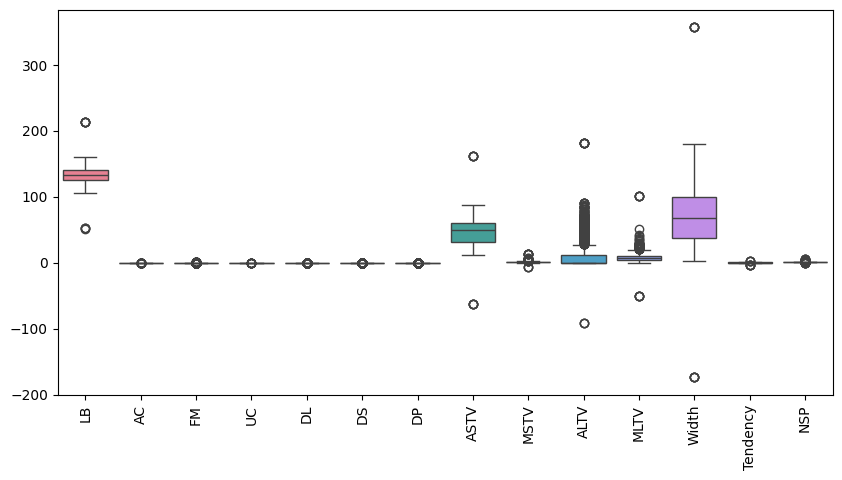

In [40]:
# detecting the outliers
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

In [41]:
# removing extreme outliers
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3-Q1
df = df[~((df < (Q1 - 1.5 * IQR)) | (df> (Q3+1.5 *IQR))).any(axis=1)]

In [42]:
df.describe()

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
count,883.000000,883.000000,883.000000,883.000000,883.000000,883.0,883.0,883.000000,883.000000,883.000000,883.000000,883.000000,883.000000,883.0
mean,131.842621,0.004071,0.000603,0.004952,0.001545,0.0,0.0,42.401260,1.271275,3.170071,8.613856,67.795732,0.338671,1.0
std,9.461012,0.003726,0.001337,0.002718,0.002218,0.0,0.0,15.079872,0.538496,6.036208,4.487502,32.607863,0.588830,0.0
min,106.000000,-0.000122,-0.002467,-0.000101,-0.000124,0.0,0.0,15.000000,0.300000,-1.043619,-0.136053,12.000000,-1.006614,1.0
25%,125.000000,0.000000,0.000000,0.003098,0.000000,0.0,0.0,29.000000,0.900000,0.000000,5.600000,40.000000,0.000000,1.0
50%,133.000000,0.003350,0.000000,0.005051,0.000000,0.0,0.0,41.000000,1.200000,0.000000,8.500000,61.000000,0.000000,1.0
75%,138.000000,0.006719,0.000336,0.006927,0.003084,0.0,0.0,56.000000,1.600000,4.000000,11.400000,92.408185,1.000000,1.0
max,160.000000,0.013861,0.006272,0.012072,0.008197,0.0,0.0,79.000000,3.200000,27.000000,20.000000,176.310998,1.023635,1.0


In [43]:
# getting median and IQR
df.median()
df.quantile(0.75) - df.quantile(0.25)

,0
LB,13.000000
AC,0.006719
FM,0.000336
UC,0.003830
DL,0.003084
DS,0.000000
DP,0.000000
ASTV,27.000000
MSTV,0.700000
ALTV,4.000000


In [44]:
# DATA VISUALIZATION

# **VISUALIZATION**

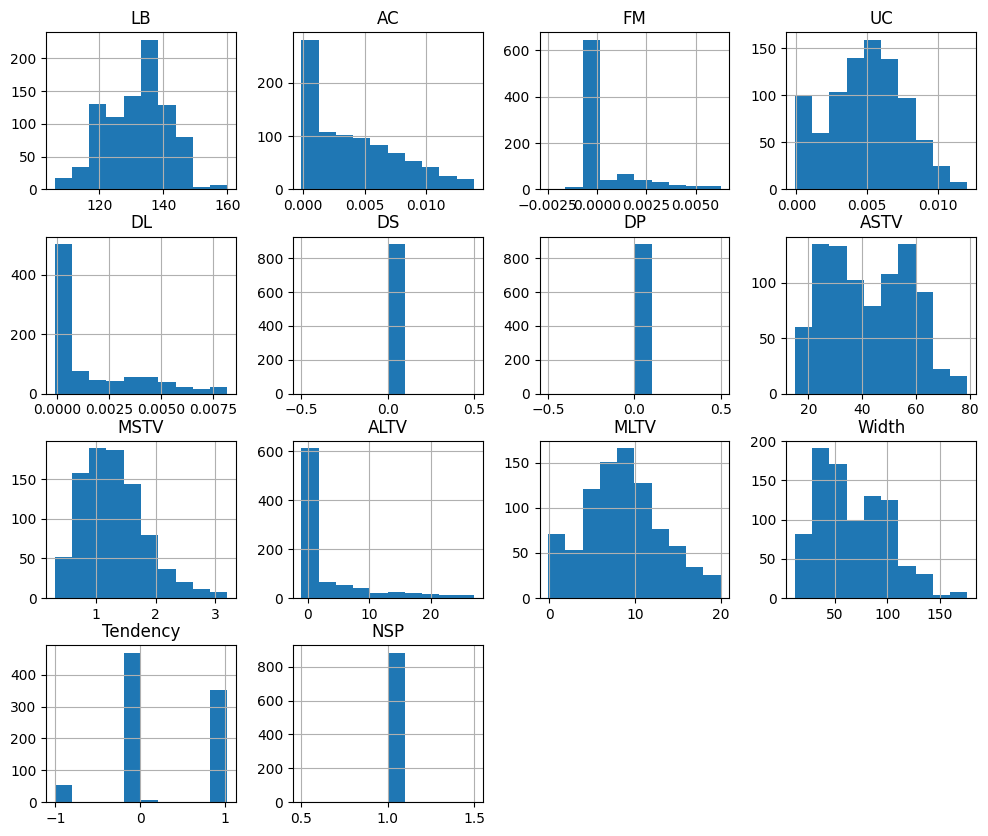

In [45]:
df.hist(figsize=(12,10)) # producing histograms
plt.show()

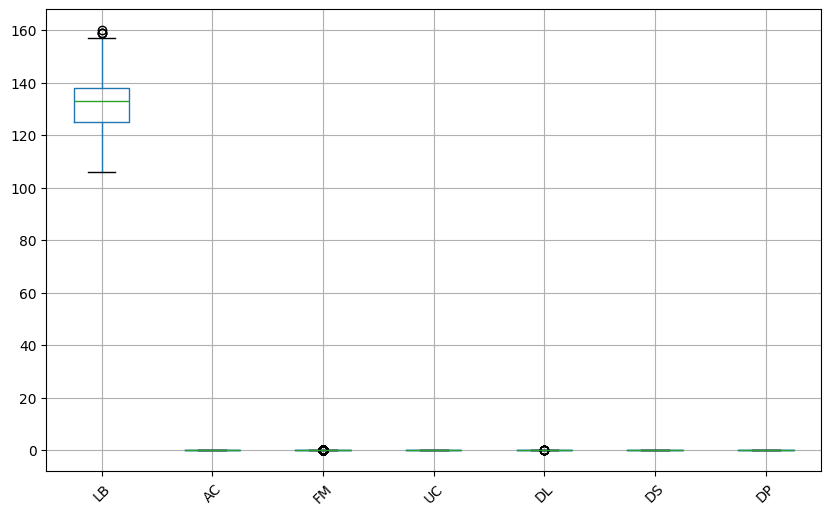

In [47]:
# producing boxplots using imp variables for ouliers
cols = ["LB","AC","FM","UC","DL","DS","DP"]
df[cols].boxplot(figsize=(10,6))
plt.xticks(rotation=45)
plt.show()

In [49]:
# for correlation  heatmap

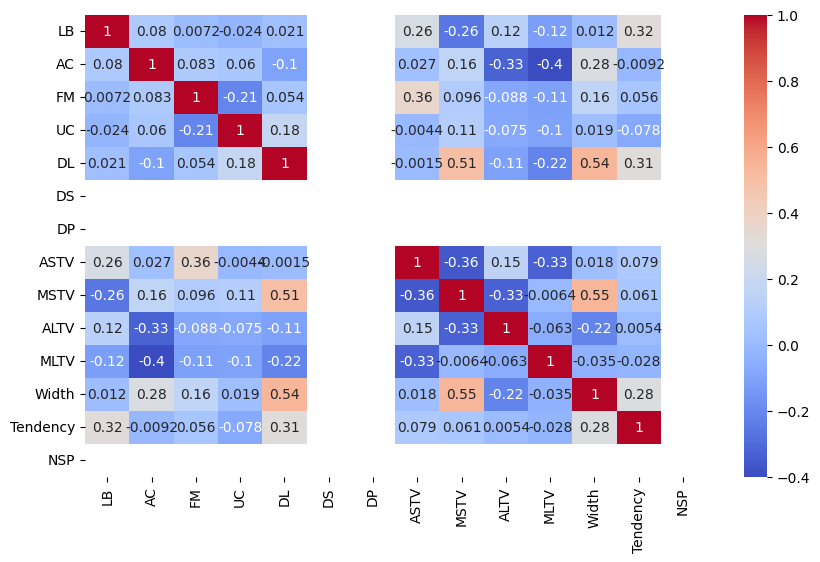

In [52]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(),annot=True,cmap="coolwarm")
plt.show()

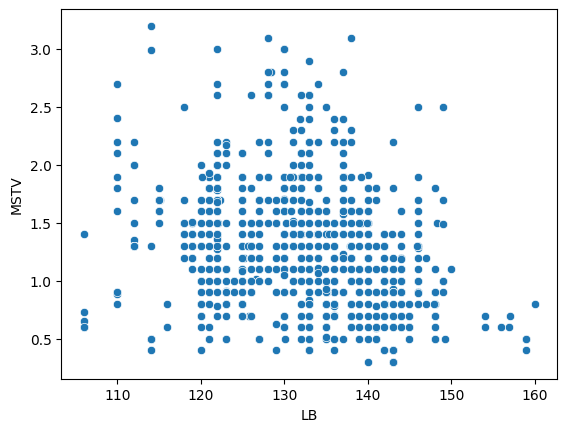

In [53]:
# scatter plot
sns.scatterplot(x="LB",y = "MSTV",data=df)
plt.show()

In [54]:
# it is not corelated type

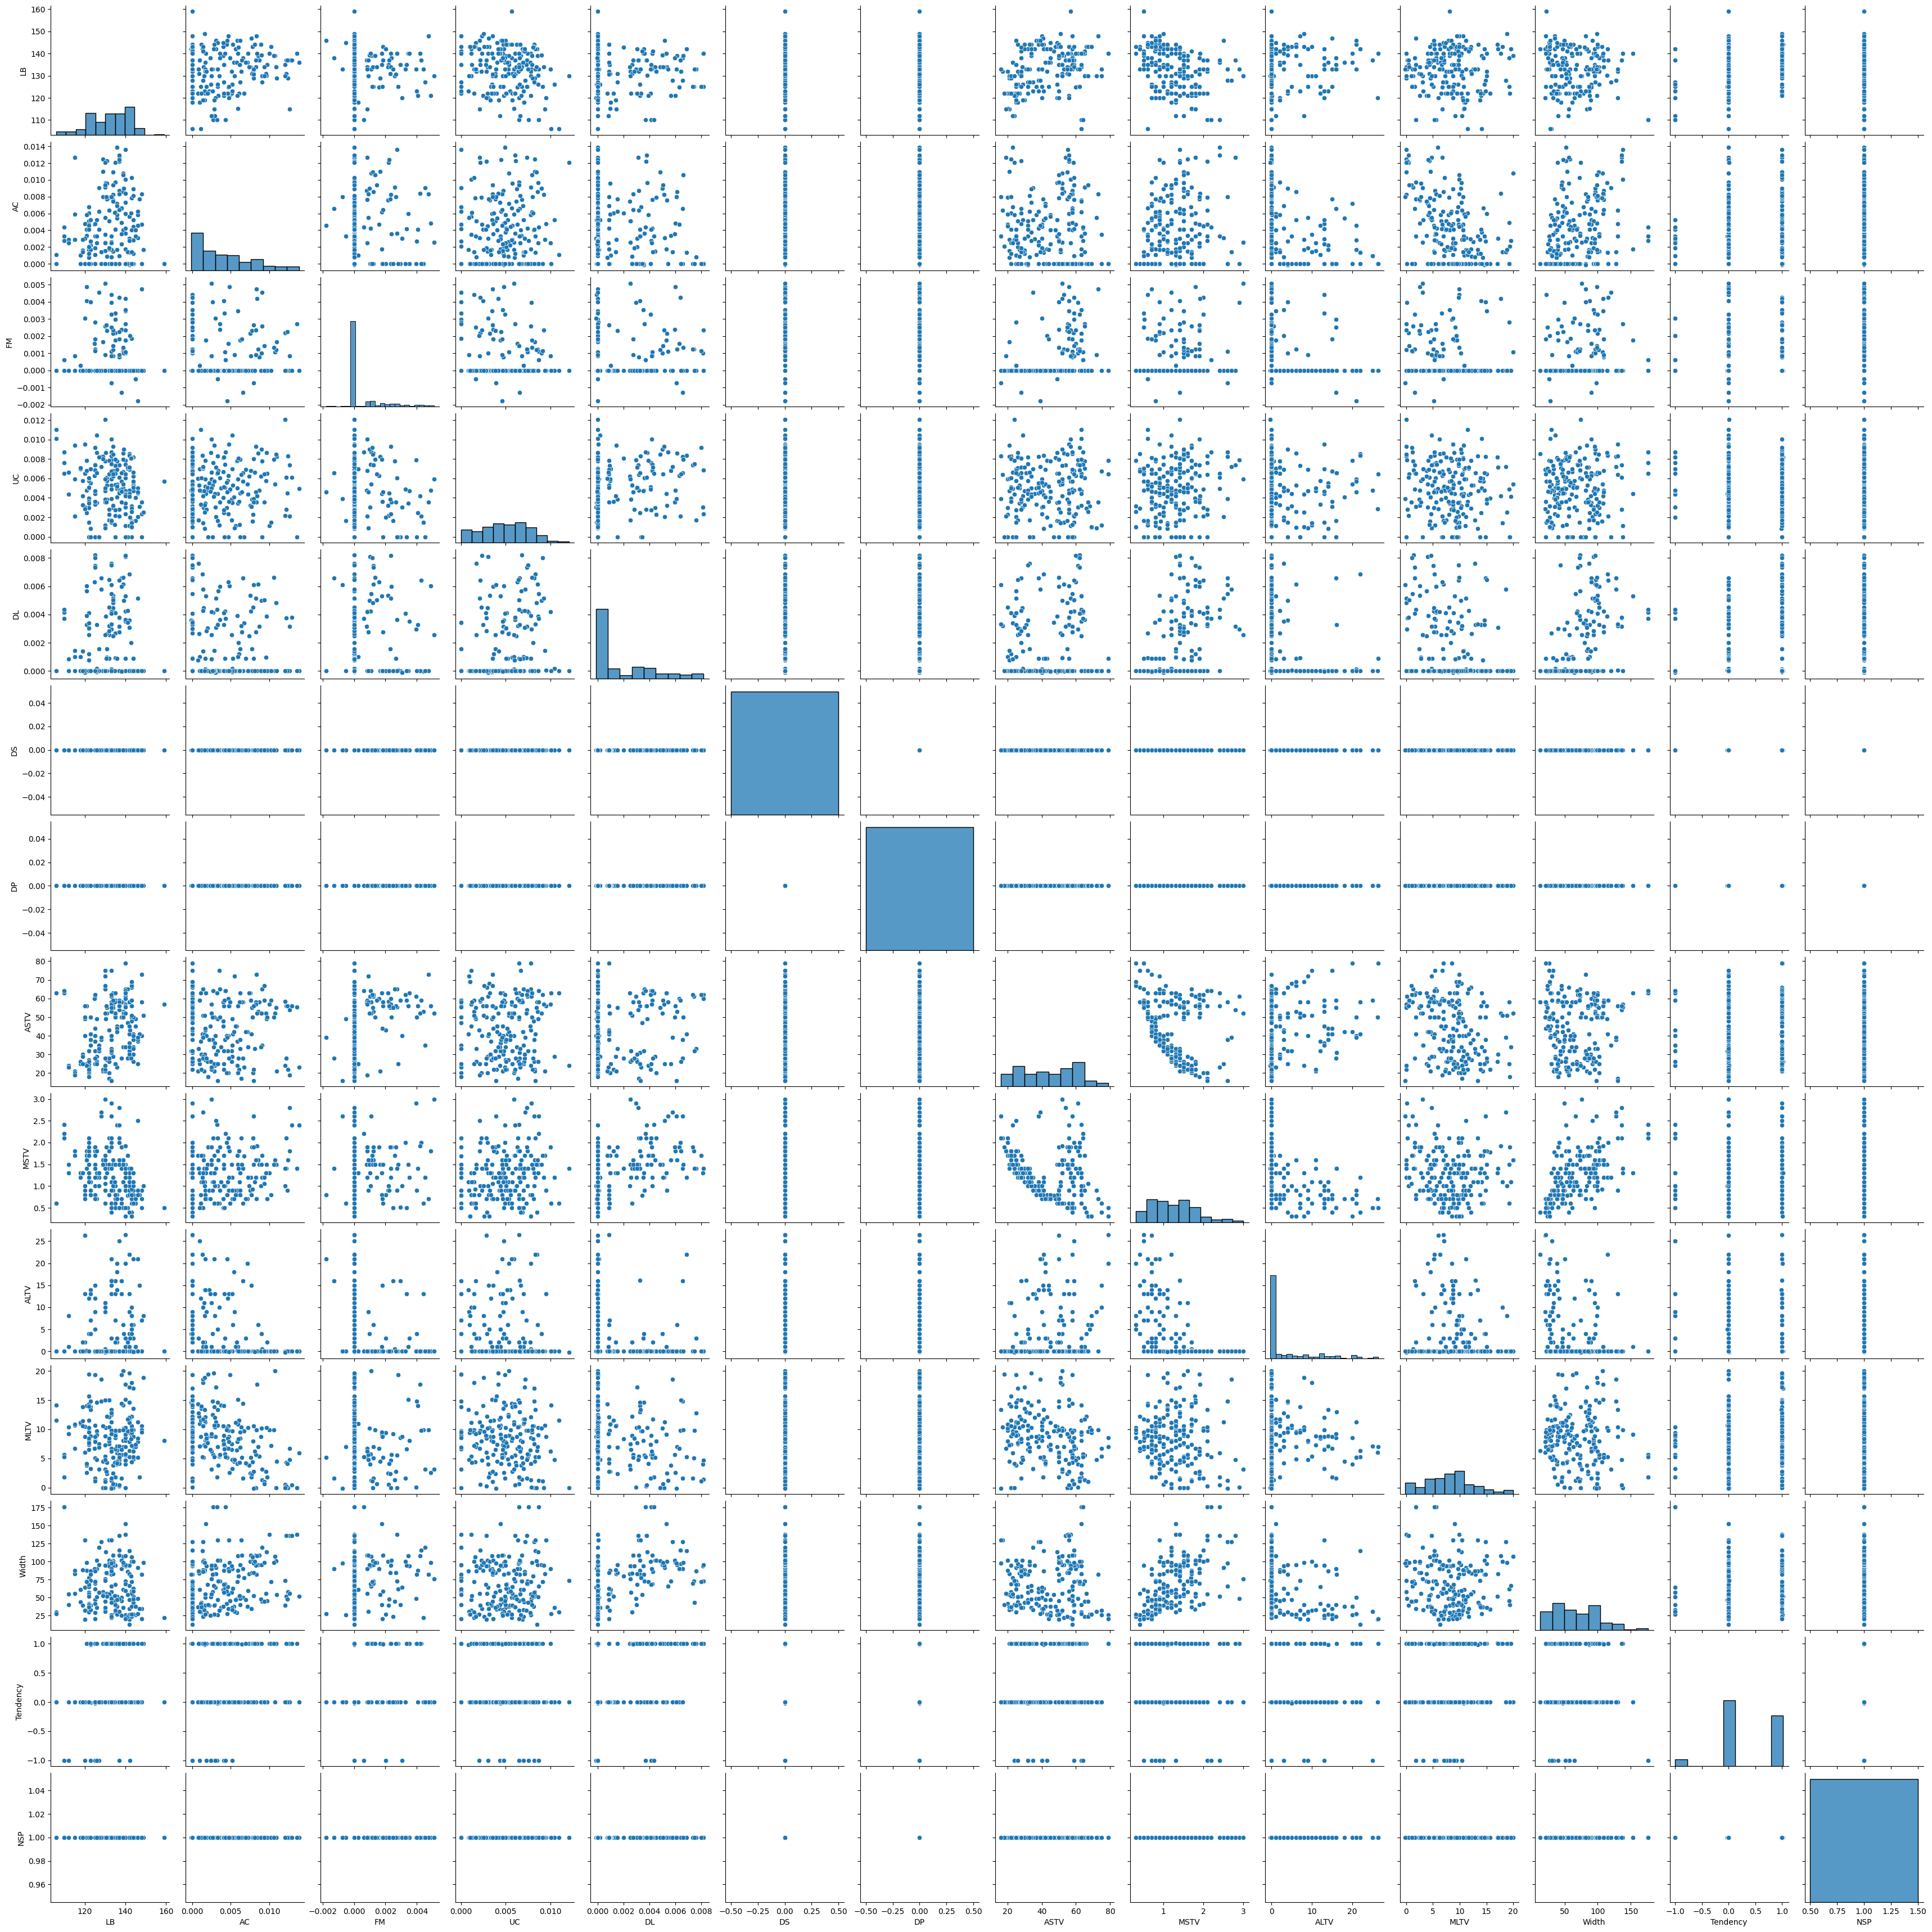

In [56]:
# pairplot
sns.pairplot(df.sample(200))   # use sample to avoid late/lag
plt.show()

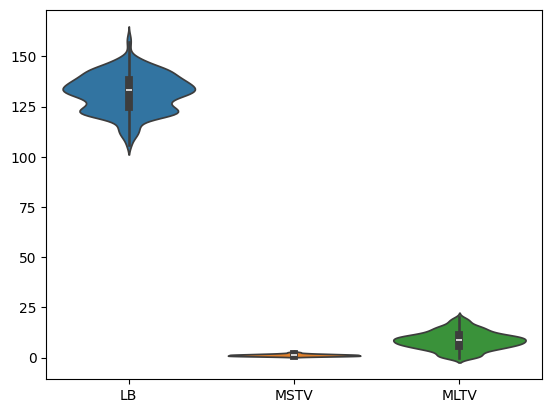

In [57]:
#violin plot
sns.violinplot(data=df[["LB","MSTV","MLTV"]])
plt.show()

# **INSIGHTS**

In [58]:
#1 We can observe that LB (FHR) mostly range is in btwn 120-140 i.e. normal
#2 Higher AC(Acceleration) ~ better fetal health
#3 high DL/DP(Decleration) ~ possible risk
#4 MSTV/MLTV show variability ~ important for diagnosis
#5 Heatmap shows correlation btwn (MSTV & ASTV) & (MLTV & ASTV)


# **CONCLUSION**

In [59]:
# We can observe that the Fatal Heart Range (FHR) are within normal range
# Accelerations indicate good Fetal Condition
# High declerations indicate posiible risk
# MSTV & MLTV are key indicators
# Datasets show meaningful correlation used for prediction models

In [67]:
df.to_csv("cleaned_data.csv",index=False)